# Experiment 7: Support Vector Machines (SVM)

## Objective
Apply a Support Vector Machine for binary classification.

## Problem
Use the Student Performance dataset from the previous experiments to predict:

- `pass_fail = 0` → Fail
- `pass_fail = 1` → Pass

## Requirements
Python, Pandas, NumPy, Matplotlib, Seaborn, scikit-learn, Jupyter/Google Colab, and `student_performance.csv`.

## Learning Outcomes
Students will learn to:

1. Explain hyperplanes, margins, support vectors and kernels.
2. Prepare and standardize data without leakage.
3. Train linear and RBF-kernel SVM classifiers.
4. Evaluate predictions using several classification metrics.
5. Visualize a two-feature decision boundary.
6. Interpret the effects of `C`, `gamma` and kernel choice.
7. Compare SVM with a majority-class baseline.

## 1. SVM Theory

An SVM searches for a separating **hyperplane** with the largest possible margin between classes.

For a linear SVM, the boundary is:
\[
w^Tx+b=0
\]

The points closest to this boundary are **support vectors**. They have the greatest influence on the learned boundary.

### Soft Margin and C

Real data may not be perfectly separable. A soft-margin SVM allows some violations.

- Smaller `C`: stronger regularization, wider margin, more violations allowed.
- Larger `C`: stronger penalty for violations, potentially narrower margin and overfitting.

### Kernel Trick

A kernel lets SVM learn nonlinear boundaries without explicitly constructing every transformed feature.

Common kernels:

- `linear`: straight hyperplane
- `rbf`: flexible nonlinear boundary
- `poly`: polynomial boundary
- `sigmoid`: sigmoid-based similarity

For RBF:
\[
K(x_i,x_j)=\exp(-\gamma\|x_i-x_j\|^2)
\]

- Small `gamma`: smoother, broader influence.
- Large `gamma`: highly local, complex boundary.

SVM is sensitive to feature scale; therefore standardization is essential.

## 2. Import Required Libraries

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load the Student Performance Dataset

In [2]:
DATA_PATH = Path("/kaggle/input/datasets/tahreemrashid/student-performance-dataset/student_performance.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "student_performance.csv was not found. Place it beside this notebook "
        "or change DATA_PATH to its location."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())
df.info()

Dataset shape: (1000, 15)


,student_id,name,gender,age,class,teacher_id,subject,test1_score,test2_score,final_exam_score,final_grade_letter,attendance_percentage,study_hours_per_week,assignments_submitted,pass_fail
0,1,Carson Rivera,Female,14,9th,105,Math,23.5,40.5,50.5,F,70.2,3.1,56.7,0
1,2,Ashley Walters,Male,15,10th,107,Computer,77.7,80.6,82.3,B,85.3,6.9,81.0,1
2,3,Linda Robinson,Male,15,10th,103,English,75.0,73.4,64.5,C,83.1,4.3,66.3,1
3,4,Brandon James,Female,17,11th,117,Computer,46.7,53.1,51.2,F,74.1,0.4,44.9,0
4,5,Helen Grant,Female,16,10th,112,Science,38.0,57.3,47.6,F,73.8,1.4,49.9,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             1000 non-null   int64  
 1   name                   1000 non-null   object 
 2   gender                 1000 non-null   object 
 3   age                    1000 non-null   int64  
 4   class                  1000 non-null   object 
 5   teacher_id             1000 non-null   int64  
 6   subject                1000 non-null   object 
 7   test1_score            1000 non-null   float64
 8   test2_score            1000 non-null   float64
 9   final_exam_score       1000 non-null   float64
 10  final_grade_letter     1000 non-null   object 
 11  attendance_percentage  1000 non-null   float64
 12  study_hours_per_week   1000 non-null   float64
 13  assignments_submitted  1000 non-null   float64
 14  pass_fail              1000 non-null   int64  
dtypes: fl

## 4. Select Features and Target

Use measurements that should be available before the final result:

- `test1_score`
- `test2_score`
- `attendance_percentage`
- `study_hours_per_week`
- `assignments_submitted`

Exclude `final_exam_score` and `final_grade_letter` because they may reveal the target. Exclude student names and IDs from predictors.

In [3]:
FEATURES = [
    "test1_score",
    "test2_score",
    "attendance_percentage",
    "study_hours_per_week",
    "assignments_submitted"
]
TARGET = "pass_fail"

missing_columns = sorted(set(FEATURES + [TARGET]) - set(df.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

data = df.drop_duplicates().copy()
print("Exact duplicate rows removed:", len(df) - len(data))

numeric_target = pd.to_numeric(data[TARGET], errors="coerce")
invalid_target = data[TARGET].notna() & (
    numeric_target.isna() | ~numeric_target.isin([0, 1])
)
if invalid_target.any():
    raise ValueError("pass_fail must contain only 0, 1, or missing values.")

print("Rows with missing target removed:", numeric_target.isna().sum())
data[TARGET] = numeric_target
data = data.dropna(subset=[TARGET]).copy()
data[TARGET] = data[TARGET].astype(int)

data[FEATURES] = data[FEATURES].apply(pd.to_numeric, errors="coerce")
data[FEATURES] = data[FEATURES].replace([np.inf, -np.inf], np.nan)

if set(data[TARGET].unique()) != {0, 1}:
    raise ValueError("Both Fail and Pass examples are required.")

display(data[FEATURES].isna().sum().to_frame("Missing Values"))
display(data[FEATURES].describe().round(2))

Exact duplicate rows removed: 0
Rows with missing target removed: 0


,Missing Values
test1_score,0
test2_score,0
attendance_percentage,0
study_hours_per_week,0
assignments_submitted,0


,test1_score,test2_score,attendance_percentage,study_hours_per_week,assignments_submitted
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,63.94,66.13,82.14,4.26,68.98
std,14.76,14.95,6.90,2.29,14.09
min,17.10,24.40,63.90,0.00,22.80
25%,53.80,56.38,77.20,2.60,59.28
50%,64.00,65.70,82.10,4.10,68.50
75%,73.90,76.93,86.80,5.82,79.10
max,100.00,100.00,100.00,12.00,100.00


## 5. Examine Class Balance

,Class,Count,Percentage
0,Fail,170,17.0
1,Pass,830,83.0


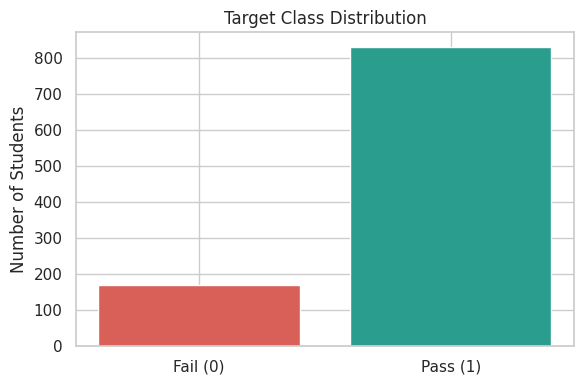

In [4]:
class_counts = data[TARGET].value_counts().reindex([0, 1], fill_value=0)

display(pd.DataFrame({
    "Class": ["Fail", "Pass"],
    "Count": class_counts.to_numpy(),
    "Percentage": 100 * class_counts.to_numpy() / len(data)
}).round(2))

plt.figure(figsize=(6, 4))
plt.bar(["Fail (0)", "Pass (1)"], class_counts,
        color=["#d95f59", "#2a9d8f"])
plt.title("Target Class Distribution")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

## 6. Split the Data

Use an 80:20 split.

- A stratified split is used when each student occurs once.
- A grouped split is used when the same student has multiple records, preventing that student from appearing in both training and testing data.

Preprocessing is fitted only on training data.

In [5]:
X = data[FEATURES]
y = data[TARGET]

repeated_students = (
    "student_id" in data.columns and data["student_id"].duplicated().any()
)

if repeated_students:
    if data["student_id"].isna().any():
        raise ValueError("Resolve missing student IDs before grouped splitting.")

    splitter = GroupShuffleSplit(
        n_splits=1, test_size=0.20, random_state=RANDOM_STATE
    )
    train_idx, test_idx = next(
        splitter.split(X, y, groups=data["student_id"])
    )
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    assert set(data.loc[X_train.index, "student_id"]).isdisjoint(
        set(data.loc[X_test.index, "student_id"])
    )
    print("Student-grouped split used.")
else:
    if y.value_counts().min() < 2:
        raise ValueError("At least two records from each class are required.")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y
    )
    print("Stratified split used.")

if y_train.nunique() != 2 or y_test.nunique() != 2:
    raise ValueError("Both classes must occur in training and testing sets.")

if X_train.isna().all().any():
    raise ValueError("A feature is entirely missing in the training partition.")

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))
display(pd.DataFrame({
    "Training": y_train.value_counts(),
    "Testing": y_test.value_counts()
}).rename(index={0: "Fail", 1: "Pass"}))

Stratified split used.
Training samples: 800
Testing samples : 200


,Training,Testing
pass_fail,,
Pass,664,166
Fail,136,34


## 7. Build a Leakage-Safe SVM Pipeline

The pipeline:

1. Replaces missing inputs with training-set medians.
2. Standardizes inputs using training-set statistics.
3. Fits an RBF-kernel SVM.

`probability=True` enables estimated class probabilities. It adds computational cost because probability calibration is performed internally.

In [6]:
svm_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        random_state=RANDOM_STATE
    ))
])

svm_model.fit(X_train, y_train)
svm_classifier = svm_model.named_steps["classifier"]

print("SVM trained successfully.")
print("Classes:", svm_classifier.classes_)
print("Support vectors per class:", svm_classifier.n_support_)
print("Total support vectors:", svm_classifier.support_vectors_.shape[0])

SVM trained successfully.
Classes: [0 1]
Support vectors per class: [60 72]
Total support vectors: 132


## 8. Generate Predictions and Probabilities

In [7]:
y_pred = svm_model.predict(X_test)
pass_index = list(svm_model.classes_).index(1)
pass_probability = svm_model.predict_proba(X_test)[:, pass_index]
decision_scores = svm_model.decision_function(X_test)

prediction_table = X_test.copy()
prediction_table["Actual"] = y_test.map({0: "Fail", 1: "Pass"})
prediction_table["Decision Score"] = decision_scores
prediction_table["P(Pass)"] = pass_probability
prediction_table["Predicted"] = pd.Series(
    y_pred, index=X_test.index
).map({0: "Fail", 1: "Pass"})
prediction_table["Correct"] = y_test.to_numpy() == y_pred

display(prediction_table.head(15).round(3))

,test1_score,test2_score,attendance_percentage,study_hours_per_week,assignments_submitted,Actual,Decision Score,P(Pass),Predicted,Correct
438,62.3,56.1,64.5,3.1,35.3,Fail,-1.108,0.050,Fail,True
875,43.6,42.5,71.7,0.0,52.4,Fail,-1.169,0.042,Fail,True
154,62.0,73.1,90.6,5.0,66.3,Pass,1.694,0.992,Pass,True
664,57.4,59.0,80.1,3.9,66.9,Pass,2.231,1.000,Pass,True
984,45.1,44.4,77.2,2.7,68.6,Fail,-0.318,0.315,Fail,True
476,70.4,86.0,93.8,5.5,88.1,Pass,1.136,0.964,Pass,True
406,60.3,62.2,78.7,1.5,53.3,Pass,1.082,0.958,Pass,True
912,52.4,69.5,75.4,2.7,52.2,Pass,0.626,0.865,Pass,True
12,56.8,61.4,79.4,3.3,58.5,Pass,1.714,0.993,Pass,True
854,56.0,47.9,83.8,1.9,67.4,Pass,1.435,0.984,Pass,True


## 9. Evaluate the Model

- **Accuracy:** fraction of all correct predictions
- **Precision (Pass):** reliability of Pass predictions
- **Recall (Pass):** fraction of actual Pass records found
- **F1-score:** balance between precision and recall
- **ROC-AUC:** ranking ability across thresholds

Always compare the SVM with a simple baseline.

In [8]:
baseline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])
baseline.fit(X_train, y_train)

def evaluate(name, model):
    predicted = model.predict(X_test)
    probabilities = model.predict_proba(X_test)
    positive_index = list(model.classes_).index(1)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, predicted),
        "Precision (Pass)": precision_score(
            y_test, predicted, zero_division=0
        ),
        "Recall (Pass)": recall_score(
            y_test, predicted, zero_division=0
        ),
        "F1 (Pass)": f1_score(
            y_test, predicted, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test, probabilities[:, positive_index]
        )
    }

comparison = pd.DataFrame([
    evaluate("Majority Baseline", baseline),
    evaluate("RBF SVM", svm_model)
]).set_index("Model")

display(comparison.round(4))

print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Fail", "Pass"],
    zero_division=0
))

,Accuracy,Precision (Pass),Recall (Pass),F1 (Pass),ROC-AUC
Model,,,,,
Majority Baseline,0.830,0.8300,1.0000,0.9071,0.5000
RBF SVM,0.955,0.9645,0.9819,0.9731,0.9895


              precision    recall  f1-score   support

        Fail       0.90      0.82      0.86        34
        Pass       0.96      0.98      0.97       166

    accuracy                           0.95       200
   macro avg       0.93      0.90      0.92       200
weighted avg       0.95      0.95      0.95       200



## 10. Confusion Matrix

True Negatives : 28
False Positives: 6
False Negatives: 3
True Positives : 163


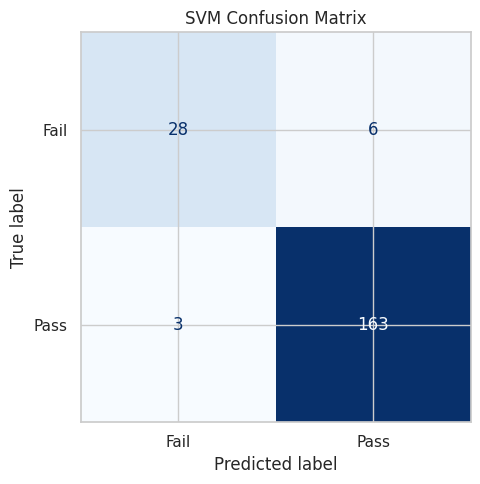

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("SVM Confusion Matrix")
plt.tight_layout()
plt.show()

## 11. ROC Curve

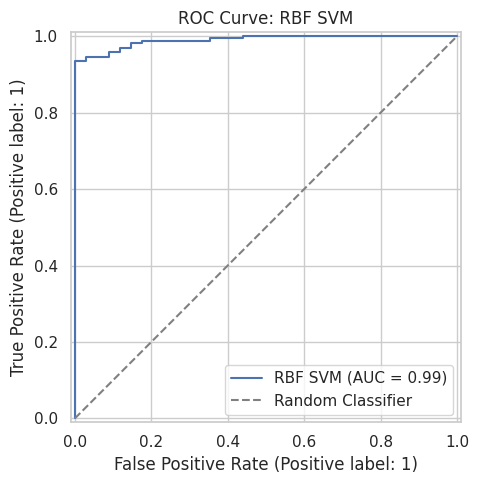

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    y_test,
    pass_probability,
    name="RBF SVM",
    ax=ax
)
ax.plot([0, 1], [0, 1], "--", color="gray", label="Random Classifier")
ax.set_title("ROC Curve: RBF SVM")
ax.legend()
plt.tight_layout()
plt.show()

## 12. Compare Linear and RBF Kernels

This is a teaching comparison on the same fixed split.

- Linear kernel learns a straight hyperplane.
- RBF kernel can learn a nonlinear boundary.

Do not select the final kernel based on test performance. Proper model selection requires cross-validation using training data only.

In [11]:
kernel_models = {}

for kernel_name in ["linear", "rbf"]:
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("classifier", SVC(
            kernel=kernel_name,
            C=1.0,
            gamma="scale",
            probability=True,
            random_state=RANDOM_STATE
        ))
    ])
    model.fit(X_train, y_train)
    kernel_models[kernel_name] = model

kernel_results = []

for kernel_name, model in kernel_models.items():
    predicted = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, list(model.classes_).index(1)]
    kernel_results.append({
        "Kernel": kernel_name,
        "Training Accuracy": model.score(X_train, y_train),
        "Testing Accuracy": accuracy_score(y_test, predicted),
        "F1 (Pass)": f1_score(y_test, predicted, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
        "Support Vectors": model.named_steps["classifier"].support_.size
    })

display(pd.DataFrame(kernel_results).set_index("Kernel").round(4))

,Training Accuracy,Testing Accuracy,F1 (Pass),ROC-AUC,Support Vectors
Kernel,,,,,
linear,0.9525,0.930,0.9583,0.9655,110
rbf,0.9612,0.955,0.9731,0.9895,132


## 13. Visualize a Two-Feature Decision Boundary

A classifier using only `test1_score` and `test2_score` is trained solely for two-dimensional visualization. It is different from the main five-feature model.

The background represents predicted regions. The dashed contour is the decision boundary.

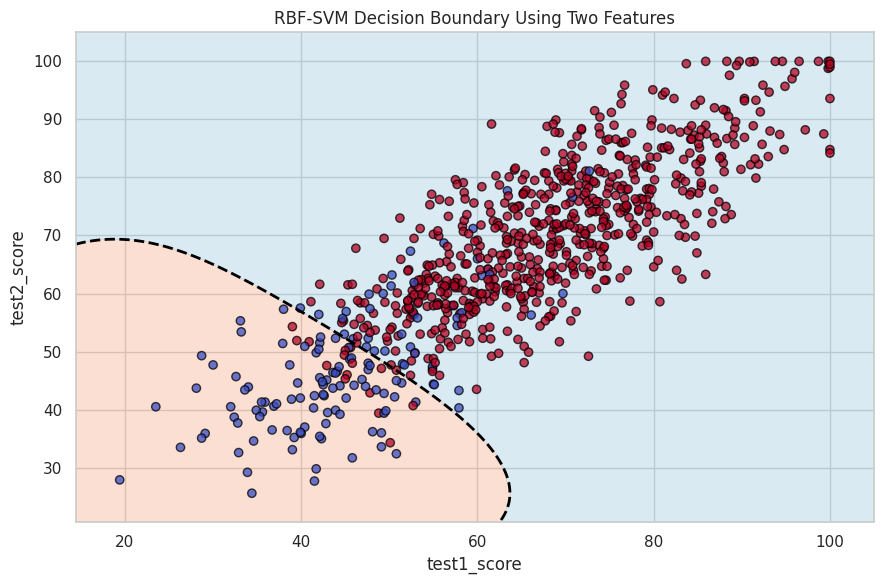

In [12]:
PLOT_FEATURES = ["test1_score", "test2_score"]

visual_svm = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        random_state=RANDOM_STATE
    ))
])
visual_svm.fit(X_train[PLOT_FEATURES], y_train)

x_min, x_max = (
    X_train[PLOT_FEATURES[0]].min() - 5,
    X_train[PLOT_FEATURES[0]].max() + 5
)
y_min, y_max = (
    X_train[PLOT_FEATURES[1]].min() - 5,
    X_train[PLOT_FEATURES[1]].max() + 5
)

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 250),
    np.linspace(y_min, y_max, 250)
)

grid = pd.DataFrame({
    PLOT_FEATURES[0]: xx.ravel(),
    PLOT_FEATURES[1]: yy.ravel()
})

grid_class = visual_svm.predict(grid).reshape(xx.shape)
grid_score = visual_svm.decision_function(grid).reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(
    xx, yy, grid_class,
    levels=[-0.5, 0.5, 1.5],
    colors=["#f4a582", "#92c5de"],
    alpha=0.35
)
plt.contour(
    xx, yy, grid_score,
    levels=[0],
    colors="black",
    linestyles="--",
    linewidths=2
)
plt.scatter(
    X_train[PLOT_FEATURES[0]],
    X_train[PLOT_FEATURES[1]],
    c=y_train,
    cmap="coolwarm",
    edgecolor="black",
    alpha=0.75
)
plt.xlabel(PLOT_FEATURES[0])
plt.ylabel(PLOT_FEATURES[1])
plt.title("RBF-SVM Decision Boundary Using Two Features")
plt.tight_layout()
plt.show()

## 14. Visualize Support Vectors in Standardized Space

The following graph shows support vectors of the two-feature visualization model. The axes are standardized values rather than original scores.

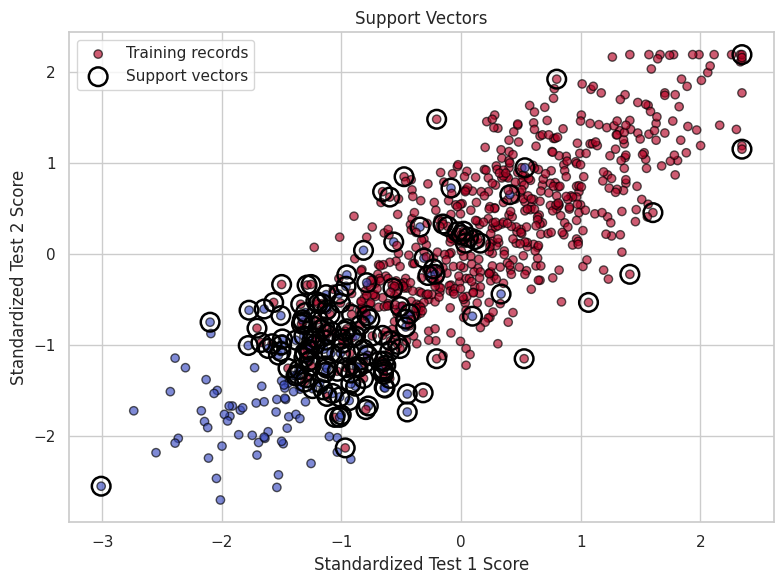

In [13]:
X_two_imputed = visual_svm.named_steps["imputer"].transform(
    X_train[PLOT_FEATURES]
)
X_two_scaled = visual_svm.named_steps["scaler"].transform(
    X_two_imputed
)
support_vectors = visual_svm.named_steps["classifier"].support_vectors_

plt.figure(figsize=(8, 6))
plt.scatter(
    X_two_scaled[:, 0],
    X_two_scaled[:, 1],
    c=y_train,
    cmap="coolwarm",
    edgecolor="black",
    alpha=0.65,
    label="Training records"
)
plt.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=180,
    facecolors="none",
    edgecolors="black",
    linewidths=1.8,
    label="Support vectors"
)
plt.xlabel("Standardized Test 1 Score")
plt.ylabel("Standardized Test 2 Score")
plt.title("Support Vectors")
plt.legend()
plt.tight_layout()
plt.show()

## 15. Effect of C

This demonstration changes `C` while keeping the RBF kernel and all other settings fixed.

Do not choose `C` from the final test results. Use training-only cross-validation for hyperparameter tuning.

,C,Training Accuracy,Testing Accuracy,F1 (Pass),Support Vectors
0,0.01,0.8300,0.830,0.9071,276
1,0.10,0.9512,0.935,0.9614,208
2,1.00,0.9612,0.955,0.9731,132
3,10.00,0.9750,0.975,0.9849,97
4,100.00,0.9838,0.975,0.9848,82


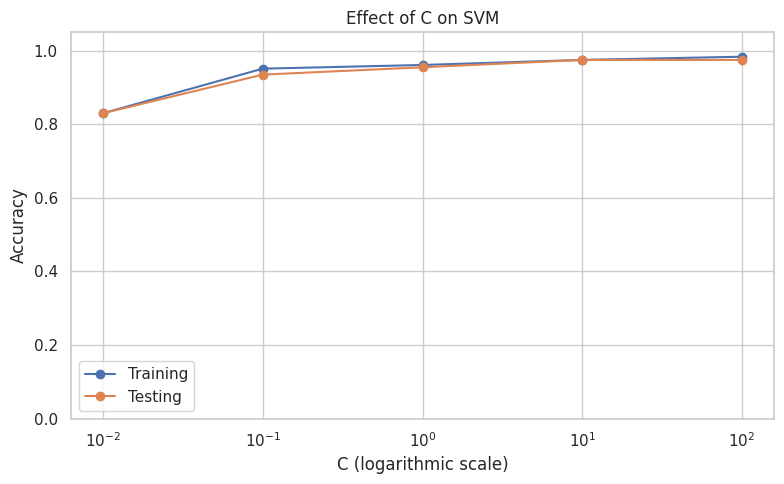

In [14]:
c_values = [0.01, 0.1, 1, 10, 100]
c_rows = []

for c_value in c_values:
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("classifier", SVC(
            kernel="rbf",
            C=c_value,
            gamma="scale",
            random_state=RANDOM_STATE
        ))
    ])
    model.fit(X_train, y_train)
    predicted = model.predict(X_test)

    c_rows.append({
        "C": c_value,
        "Training Accuracy": model.score(X_train, y_train),
        "Testing Accuracy": accuracy_score(y_test, predicted),
        "F1 (Pass)": f1_score(y_test, predicted, zero_division=0),
        "Support Vectors": model.named_steps["classifier"].support_.size
    })

c_results = pd.DataFrame(c_rows)
display(c_results.round(4))

plt.figure(figsize=(8, 5))
plt.semilogx(c_results["C"], c_results["Training Accuracy"],
             marker="o", label="Training")
plt.semilogx(c_results["C"], c_results["Testing Accuracy"],
             marker="o", label="Testing")
plt.xlabel("C (logarithmic scale)")
plt.ylabel("Accuracy")
plt.title("Effect of C on SVM")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

## 16. Predict for a New Student

This record is hypothetical. Use the same units as the original dataset. The prediction is an educational estimate and should not automatically determine academic decisions.

In [15]:
new_student = pd.DataFrame([{
    "test1_score": 65,
    "test2_score": 70,
    "attendance_percentage": 85,
    "study_hours_per_week": 12,
    "assignments_submitted": 90
}])

new_class = svm_model.predict(new_student)[0]
new_probability = svm_model.predict_proba(new_student)[0, pass_index]
new_score = svm_model.decision_function(new_student)[0]

print("Predicted class:", "Pass" if new_class == 1 else "Fail")
print(f"Estimated probability of Pass: {new_probability:.2%}")
print(f"Decision score: {new_score:.4f}")

Predicted class: Pass
Estimated probability of Pass: 87.81%
Decision score: 0.6682


## 17. Conclusion

An SVM classifier was implemented to predict Pass or Fail using standardized Student Performance features. The RBF kernel enabled a nonlinear decision boundary. The model was evaluated with accuracy, precision, recall, F1-score, ROC-AUC and a confusion matrix. Support vectors, kernel choice and the effect of `C` were also examined.

### Observation Template

“Using ___ training records and ___ testing records, the RBF-SVM used ___ support vectors and achieved accuracy ___, F1-score ___ and ROC-AUC ___. Compared with the majority baseline, ___. The linear/RBF kernel performed better in the teaching comparison, but final selection requires training-only cross-validation.”

### Limitations

- SVM can be slow on very large datasets.
- Results depend strongly on scaling, `C`, `gamma` and kernel choice.
- Probability estimation increases computation.
- The RBF model is less interpretable than a linear model or small tree.
- Predictions show association, not causation.

## Viva Questions with Short Answers

1. **What is SVM?** A supervised algorithm that finds a maximum-margin decision boundary.
2. **What is a hyperplane?** The boundary that separates classes in feature space.
3. **What is the margin?** The distance between the boundary and the nearest training points.
4. **What are support vectors?** Training points closest to or violating the margin that influence the boundary.
5. **What does C control?** The penalty for margin violations.
6. **What happens when C is very large?** The model penalizes violations strongly and may fit training data too closely.
7. **What happens when C is small?** The model accepts more violations for stronger regularization and a wider margin.
8. **Why standardize features?** SVM relies on distances and dot products, so unequal scales can dominate.
9. **What is a kernel?** A similarity function that enables nonlinear separation.
10. **What does gamma control in RBF SVM?** The range of influence of each training point.
11. **Linear versus RBF kernel?** Linear creates a straight boundary; RBF can create nonlinear boundaries.
12. **Is SVM only for binary classification?** No; multiclass classification is constructed from multiple binary problems.
13. **What is the decision function?** A signed score representing position relative to the boundary.
14. **Why use a pipeline?** It applies identical learned preprocessing to training, testing and future data without leakage.
15. **Why exclude final scores?** They may reveal the target and may be unavailable at prediction time.
16. **Why compare against a baseline?** To check whether the classifier adds predictive value.
17. **Can SVM probabilities be treated as certainty?** No; they are model estimates and may require calibration assessment.

## Practice Exercises

1. Compare linear, polynomial and RBF kernels using training-only cross-validation.
2. Tune `C` and `gamma` using `GridSearchCV`.
3. Try `class_weight="balanced"` and inspect Fail recall.
4. Compare Logistic Regression, Decision Tree, Random Forest and SVM using exactly the same split and metrics.
5. Use only two features and explain how the decision boundary changes.